Размер датасета: (1436, 39)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 39 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Id                 1436 non-null   int64 
 1   Model              1436 non-null   object
 2   Price              1436 non-null   int64 
 3   Age_08_04          1436 non-null   int64 
 4   Mfg_Month          1436 non-null   int64 
 5   Mfg_Year           1436 non-null   int64 
 6   KM                 1436 non-null   int64 
 7   Fuel_Type          1436 non-null   object
 8   HP                 1436 non-null   int64 
 9   Met_Color          1436 non-null   int64 
 10  Color              1436 non-null   object
 11  Automatic          1436 non-null   int64 
 12  CC                 1436 non-null   int64 
 13  Doors              1436 non-null   int64 
 14  Cylinders          1436 non-null   int64 
 15  Gears              1436 non-null   int64 
 16  Quarterly_Tax 

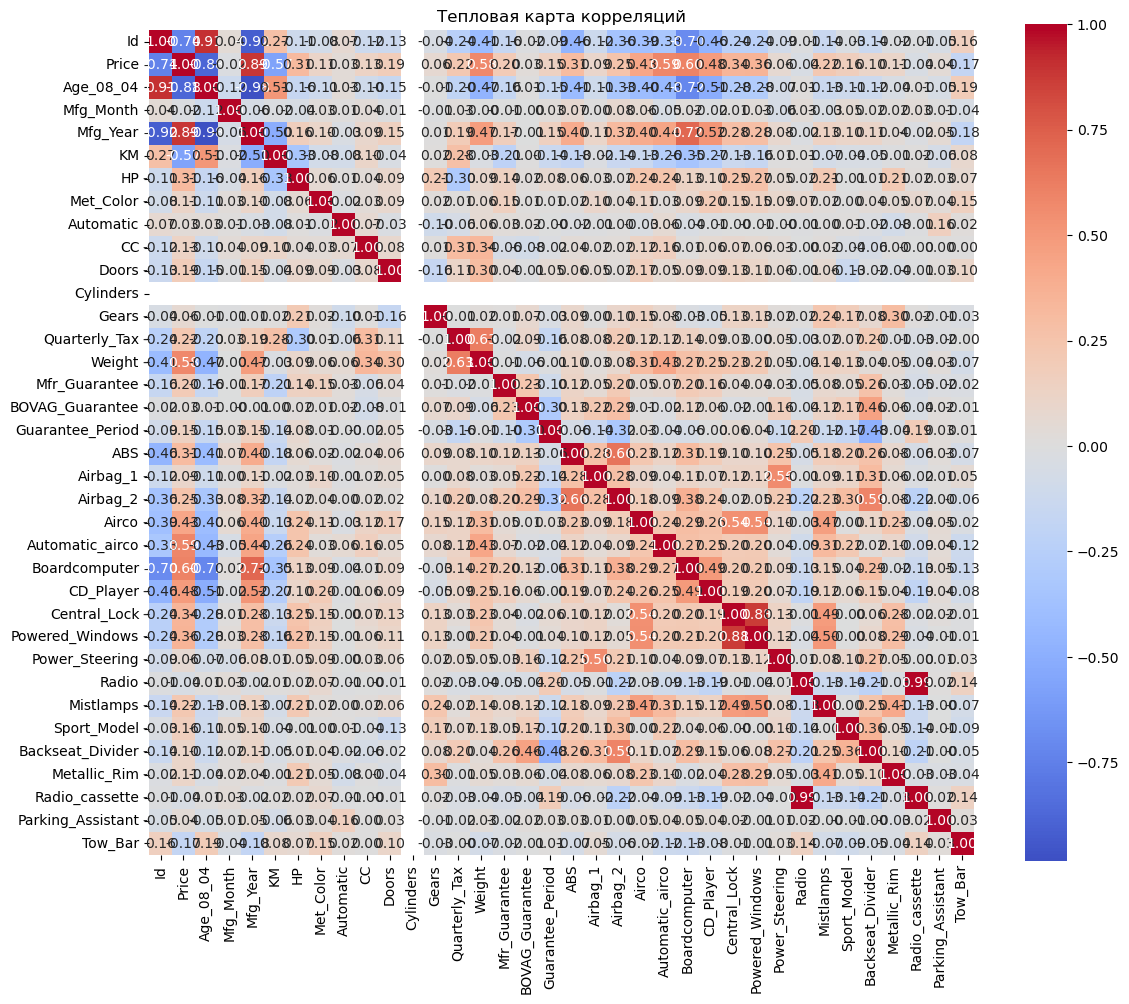


Корреляция признаков с целевой переменной:
Mfg_Year             0.885159
Boardcomputer        0.601292
Automatic_airco      0.588262
Weight               0.581198
CD_Player            0.481374
Airco                0.429259
Powered_Windows      0.356518
Central_Lock         0.343458
HP                   0.314990
ABS                  0.306138
Airbag_2             0.248974
Mistlamps            0.222083
Quarterly_Tax        0.219197
Mfr_Guarantee        0.197802
Doors                0.185326
Sport_Model          0.164121
Guarantee_Period     0.146627
CC                   0.126389
Met_Color            0.108905
Metallic_Rim         0.108564
Backseat_Divider     0.102569
Airbag_1             0.093588
Power_Steering       0.064275
Gears                0.063104
Parking_Assistant    0.044375
Automatic            0.033081
BOVAG_Guarantee      0.028133
Mfg_Month           -0.018138
Radio               -0.041887
Radio_cassette      -0.043179
Tow_Bar             -0.172369
KM                  -0.569

In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import sklearn as sk
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import seaborn as sb
df = pd.read_csv("ToyotaCorolla.csv")
print(f"Размер датасета: {df.shape}")

df.sample(5)
df.info()
df.nunique()
numeric_df = df.select_dtypes(include=['float64', 'int64'])

# Считаем корреляцию
correlation_matrix = numeric_df.corr()

# Строим тепловую карту
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, 
            annot=True,        # показывать числа
            fmt='.2f',         # формат чисел (2 знака)
            cmap='coolwarm',   # цветовая схема
            center=0,          # центр в 0
            square=True)       # квадратные ячейки
plt.title('Тепловая карта корреляций')
plt.tight_layout()
plt.show()
# Вычисляем корреляцию всех признаков с целевой переменной
correlations = numeric_df.corr()["Price"].drop("Price")

# Смотрим на корреляции
print("\nКорреляция признаков с целевой переменной:")
print(correlations.sort_values(ascending=False))

# Задаем порог (по модулю)
threshold = 0.2

# Находим признаки с низкой корреляцией (|corr| < threshold)
low_corr_features = correlations[abs(correlations) < threshold].index.tolist()
low_corr_features.append("Cylinders")
low_corr_features.append("Id")
low_corr_features.append("Model")
print(f"\nПризнаки с |корреляция| < {threshold}:")
print(low_corr_features)
print(f"\nКоличество удаляемых признаков: {len(low_corr_features)}")

# Создаем список признаков для удаления (не удаляем саму целевую переменную)
features_to_drop = low_corr_features

# Удаляем эти столбцы из исходного DataFrame
df_reduced = df.drop(columns=features_to_drop)

print(f"\nБыло признаков (без target): {len(numeric_df.columns) - 1}")
print(f"Осталось признаков (без target): {len(df_reduced.select_dtypes(include=['float64', 'int64']).columns) - 1}")

# Показываем оставшиеся числовые признаки
remaining_numeric = [col for col in df_reduced.select_dtypes(include=['float64', 'int64']).columns 
                     if col != "Price"]
print(f"\nОставшиеся числовые признаки: {remaining_numeric}")
df_reduced.head()





from sklearn.preprocessing import OneHotEncoder
import pandas as pd

# Список категориальных столбцов (обратите внимание: у вас 'Fuel_Type', а в датасете скорее 'FuelType')
categorical_cols = ['Fuel_Type', 'Color']
existing_categorical = categorical_cols

print(f"Ищем столбцы: {categorical_cols}")
print(f"Найдены в df_reduced: {existing_categorical}")

if existing_categorical:
    # Применяем OneHotEncoder
    encoder = OneHotEncoder(sparse_output=False, drop='first')
    encoded_array = encoder.fit_transform(df_reduced[existing_categorical])
    encoded_columns = encoder.get_feature_names_out(existing_categorical)
    encoded_df = pd.DataFrame(encoded_array, columns=encoded_columns, index=df_reduced.index)
    
    # Удаляем старые категориальные столбцы (используем existing_categorical)
    df_reduced = df_reduced.drop(columns=existing_categorical)
    
    # Добавляем закодированные столбцы
    df_reduced = pd.concat([df_reduced, encoded_df], axis=1)
    
    print(f"\nКодирование завершено!")
    print(f"Новый размер df_reduced: {df_reduced.shape}")
    print(f"Добавленные столбцы: {encoded_columns.tolist()}")
else:
    print("Указанные категориальные столбцы не найдены в df_reduced")
    print(f"Доступные столбцы: {df_reduced.columns.tolist()}")

# Проверяем результат
print(f"\nТипы столбцов после кодирования:")
print(df_reduced.dtypes)





from sklearn.model_selection import train_test_split

target_column = 'Price'

# X — все столбцы, кроме целевой переменной
X = df_reduced.drop(columns=[target_column])

# y — целевая переменная
y = df_reduced[target_column]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, train_size = 0.8, random_state = 42)


from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)




#непосредственно само обучение модели ridge
from sklearn.metrics import r2_score
from sklearn.linear_model import Ridge
alphas = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000]

results =[]

for alpha in alphas:
    ridge = Ridge(alpha = alpha)
    ridge.fit(X_train_scaled, y_train)
    y_pred = ridge.predict(X_test_scaled)
    r2 = r2_score(y_test, y_pred)
    results.append({
        'alpha': alpha,
        'R²': r2
    })
for result in results:
    print(f"{result}")
alpha = 167
ridge = Ridge(alpha = alpha)
ridge.fit(X_train_scaled, y_train)
y_pred = ridge.predict(X_test_scaled)
r2_itog = r2_score(y_test, y_pred)
print(f"Обучение прошло успешно, в результате: r2_score = {r2_itog}")

In [2]:
# Находим признаки с низкой корреляцией (|corr| < threshold)
low_corr_features = correlations[abs(correlations) < threshold].index.tolist()
low_corr_features.append("Cylinders")
low_corr_features.append("Id")
low_corr_features.append("Model")
print(f"\nПризнаки с |корреляция| < {threshold}:")
print(low_corr_features)
print(f"\nКоличество удаляемых признаков: {len(low_corr_features)}")

# Создаем список признаков для удаления (не удаляем саму целевую переменную)
features_to_drop = low_corr_features

# Удаляем эти столбцы из исходного DataFrame
df_reduced = df.drop(columns=features_to_drop)

print(f"\nБыло признаков (без target): {len(numeric_df.columns) - 1}")
print(f"Осталось признаков (без target): {len(df_reduced.select_dtypes(include=['float64', 'int64']).columns) - 1}")

# Показываем оставшиеся числовые признаки
remaining_numeric = [col for col in df_reduced.select_dtypes(include=['float64', 'int64']).columns 
                     if col != "Price"]
print(f"\nОставшиеся числовые признаки: {remaining_numeric}")
df_reduced.head()



Признаки с |корреляция| < 0.2:
['Mfg_Month', 'Met_Color', 'Automatic', 'CC', 'Doors', 'Gears', 'Mfr_Guarantee', 'BOVAG_Guarantee', 'Guarantee_Period', 'Airbag_1', 'Power_Steering', 'Radio', 'Sport_Model', 'Backseat_Divider', 'Metallic_Rim', 'Radio_cassette', 'Parking_Assistant', 'Tow_Bar', 'Cylinders', 'Id', 'Model']

Количество удаляемых признаков: 21

Было признаков (без target): 35
Осталось признаков (без target): 15

Оставшиеся числовые признаки: ['Age_08_04', 'Mfg_Year', 'KM', 'HP', 'Quarterly_Tax', 'Weight', 'ABS', 'Airbag_2', 'Airco', 'Automatic_airco', 'Boardcomputer', 'CD_Player', 'Central_Lock', 'Powered_Windows', 'Mistlamps']


,Price,Age_08_04,Mfg_Year,KM,Fuel_Type,HP,Color,Quarterly_Tax,Weight,ABS,Airbag_2,Airco,Automatic_airco,Boardcomputer,CD_Player,Central_Lock,Powered_Windows,Mistlamps
0,13500,23,2002,46986,Diesel,90,Blue,210,1165,1,1,0,0,1,0,1,1,0
1,13750,23,2002,72937,Diesel,90,Silver,210,1165,1,1,1,0,1,1,1,0,0
2,13950,24,2002,41711,Diesel,90,Blue,210,1165,1,1,0,0,1,0,0,0,0
3,14950,26,2002,48000,Diesel,90,Black,210,1165,1,1,0,0,1,0,0,0,0
4,13750,30,2002,38500,Diesel,90,Black,210,1170,1,1,1,0,1,0,1,1,1


In [3]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

# Список категориальных столбцов (обратите внимание: у вас 'Fuel_Type', а в датасете скорее 'FuelType')
categorical_cols = ['Fuel_Type', 'Color']
existing_categorical = categorical_cols

print(f"Ищем столбцы: {categorical_cols}")
print(f"Найдены в df_reduced: {existing_categorical}")

if existing_categorical:
    # Применяем OneHotEncoder
    encoder = OneHotEncoder(sparse_output=False, drop='first')
    encoded_array = encoder.fit_transform(df_reduced[existing_categorical])
    encoded_columns = encoder.get_feature_names_out(existing_categorical)
    encoded_df = pd.DataFrame(encoded_array, columns=encoded_columns, index=df_reduced.index)
    
    # Удаляем старые категориальные столбцы (используем existing_categorical)
    df_reduced = df_reduced.drop(columns=existing_categorical)
    
    # Добавляем закодированные столбцы
    df_reduced = pd.concat([df_reduced, encoded_df], axis=1)
    
    print(f"\nКодирование завершено!")
    print(f"Новый размер df_reduced: {df_reduced.shape}")
    print(f"Добавленные столбцы: {encoded_columns.tolist()}")
else:
    print("Указанные категориальные столбцы не найдены в df_reduced")
    print(f"Доступные столбцы: {df_reduced.columns.tolist()}")

# Проверяем результат
print(f"\nТипы столбцов после кодирования:")
print(df_reduced.dtypes)


Ищем столбцы: ['Fuel_Type', 'Color']
Найдены в df_reduced: ['Fuel_Type', 'Color']

Кодирование завершено!
Новый размер df_reduced: (1436, 27)
Добавленные столбцы: ['Fuel_Type_Diesel', 'Fuel_Type_Petrol', 'Color_Black', 'Color_Blue', 'Color_Green', 'Color_Grey', 'Color_Red', 'Color_Silver', 'Color_Violet', 'Color_White', 'Color_Yellow']

Типы столбцов после кодирования:
Price                 int64
Age_08_04             int64
Mfg_Year              int64
KM                    int64
HP                    int64
Quarterly_Tax         int64
Weight                int64
ABS                   int64
Airbag_2              int64
Airco                 int64
Automatic_airco       int64
Boardcomputer         int64
CD_Player             int64
Central_Lock          int64
Powered_Windows       int64
Mistlamps             int64
Fuel_Type_Diesel    float64
Fuel_Type_Petrol    float64
Color_Black         float64
Color_Blue          float64
Color_Green         float64
Color_Grey          float64
Color_Red   

In [4]:
from sklearn.model_selection import train_test_split

target_column = 'Price'

# X — все столбцы, кроме целевой переменной
X = df_reduced.drop(columns=[target_column])

# y — целевая переменная
y = df_reduced[target_column]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, train_size = 0.8, random_state = 42)


from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



In [5]:
#непосредственно само обучение модели ridge
from sklearn.metrics import r2_score
from sklearn.linear_model import Ridge
alphas = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000]

results =[]

for alpha in alphas:
    ridge = Ridge(alpha = alpha)
    ridge.fit(X_train_scaled, y_train)
    y_pred = ridge.predict(X_test_scaled)
    r2 = r2_score(y_test, y_pred)
    results.append({
        'alpha': alpha,
        'R²': r2
    })
for result in results:
    print(f"{result}")
alpha = 167
ridge = Ridge(alpha = alpha)
ridge.fit(X_train_scaled, y_train)
y_pred = ridge.predict(X_test_scaled)
r2_itog = r2_score(y_test, y_pred)
print(f"Обучение прошло успешно, в результате: r2_score = {r2_itog}")
df_reduced.columns

{'alpha': 0.0001, 'R²': 0.8789254694906539}
{'alpha': 0.001, 'R²': 0.8789266384787372}
{'alpha': 0.01, 'R²': 0.8789382322497743}
{'alpha': 0.1, 'R²': 0.8790454337712492}
{'alpha': 1, 'R²': 0.8796823758279035}
{'alpha': 10, 'R²': 0.8818211452538091}
{'alpha': 100, 'R²': 0.8886539502246188}
{'alpha': 1000, 'R²': 0.8543004990808376}
{'alpha': 10000, 'R²': 0.48222000272490706}
Обучение прошло успешно, в результате: r2_score = 0.8896107100173726


Index(['Price', 'Age_08_04', 'Mfg_Year', 'KM', 'HP', 'Quarterly_Tax', 'Weight',
       'ABS', 'Airbag_2', 'Airco', 'Automatic_airco', 'Boardcomputer',
       'CD_Player', 'Central_Lock', 'Powered_Windows', 'Mistlamps',
       'Fuel_Type_Diesel', 'Fuel_Type_Petrol', 'Color_Black', 'Color_Blue',
       'Color_Green', 'Color_Grey', 'Color_Red', 'Color_Silver',
       'Color_Violet', 'Color_White', 'Color_Yellow'],
      dtype='object')

In [6]:
# Данные одной машины (в том же порядке, что и столбцы выше, но без Price)
new_car = [[
    12,          # Age_08_04
    2010,        # Mfg_Year
    150000,      # KM
    110,         # HP
    200,         # Quarterly_Tax
    1200,        # Weight
    1,           # ABS (1 = есть)
    1,           # Airbag_2 (1 = есть)
    1,           # Airco
    0,           # Automatic_airco
    1,           # Boardcomputer
    1,           # CD_Player
    1,           # Central_Lock
    1,           # Powered_Windows
    1,           # Mistlamps
    0,           # Fuel_Type_Diesel (0 = не дизель)
    1,           # Fuel_Type_Petrol (1 = бензин)
    0,           # Color_Black
    0,           # Color_Blue
    0,           # Color_Green
    0,           # Color_Grey
    0,           # Color_Red
    1,           # Color_Silver
    0,           # Color_Violet
    0,           # Color_White
    0,           # Color_Yellow
]]

new_car_scale = scaler.transform(new_car)
cost = ridge.predict(new_car_scale)
print(cost[0])



21921.869201721885


D:\Anaconda\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
